# Two-Stage IoT Intrusion Detection — Session-Aware Version

This is a cleaned-up rewrite of the two-stage pipeline, fixing three leakage
issues discovered while iterating on the earlier version:

1. **Exact duplicate rows** across train/test (attack traffic is highly
   repetitive, so many rows share identical feature values) — fixed by
   deduplicating before splitting.
2. **Window-boundary overlap** at the train/test cut for a given class —
   made moot once sessions (rather than an arbitrary time percentage) define
   the split, since consecutive sessions are separated by gaps far larger
   than the 5-second rolling window.
3. **Single-session classes** — several attack types exist as exactly one
   continuous capture session in this dataset. For those, no split can
   measure genuine cross-instance generalization; this is flagged explicitly
   rather than papered over, in the Limitations section at the end.

**Read the "Session counts per class" and "Limitations & Future Work"
sections before trusting any number in this notebook at face value.**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, precision_recall_curve
)
import joblib

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


## Load data

`stime` is kept as the raw epoch integer throughout -- it's already
monotonically sortable, so no datetime conversion is needed for splitting
or windowing.

In [34]:
df = pd.read_csv(project_root / "data/raw/ACI-IoT-2023-Payload.csv")
df["stime_dt"] = pd.to_datetime(df["stime"], unit="s")
df = df.sort_values("stime_dt").reset_index(drop=True)

print(df.shape)
df.head()


(631486, 11)


,srcip,sport,dstip,dsport,protocol_m,sttl,total_len,payload,stime,label,stime_dt
0,192.168.1.81,60683,239.255.255.250,1900,udp,2,362,4e4f54494659202a20485454502f312e310d0a4e54533a...,1698670981,Benign,2023-10-30 13:03:01
1,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670984,Benign,2023-10-30 13:03:04
2,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670985,Benign,2023-10-30 13:03:05
3,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670986,Benign,2023-10-30 13:03:06
4,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670987,Benign,2023-10-30 13:03:07


## Engineer window features per (srcip, dstip)

Trailing 5-second rolling stats between each source/destination pair:

- `flow_pkt_count` -- packet rate in the window (separates floods from
  normal traffic)
- `payload_len_mean` / `payload_len_std` -- mean/spread of packet size in
  the window (turned out to be the strongest features for Stage 1 --
  see feature importances below)

`unique_dsport_ratio`, `sttl_std`, and `protocol_m` were tried and dropped:
feature-importance analysis showed they contributed almost nothing to
Stage 1 (near-zero importance), so they're left out here to keep the
feature set lean. They may still be worth revisiting for Stage 2
specifically, where subtype-distinguishing signal matters more.

In [35]:
def compute_window_features(g, window="5s"):
    g = g.sort_values("stime_dt")
    orig_index = g.index

    g = g.set_index("stime_dt")
    roll = g.rolling(window)

    out = pd.DataFrame(index=g.index)
    out["flow_pkt_count"] = roll["total_len"].count()
    out["payload_len_mean"] = roll["total_len"].mean()
    out["payload_len_std"] = roll["total_len"].std()

    out.index = orig_index
    return out

engineered = (
    df.groupby(["srcip", "dstip"], group_keys=False)
      .apply(compute_window_features)
)
engineered[["payload_len_std"]] = engineered[["payload_len_std"]].fillna(0)

df = df.join(engineered)
df[["flow_pkt_count", "payload_len_mean", "payload_len_std"]].describe()


,flow_pkt_count,payload_len_mean,payload_len_std
count,631486.000000,631486.000000,631486.000000
mean,754.071127,4308.253106,2706.069963
std,1616.817297,3098.017093,1979.860896
min,1.000000,30.000000,0.000000
25%,11.000000,432.333333,192.354228
50%,163.000000,5836.113942,3651.722008
75%,337.000000,6793.610713,4246.559930
max,8869.000000,24676.000000,11017.430758


## Select modeling columns and drop identity/raw fields

`srcip`, `dstip`, `sport`, `dsport`, `stime_dt`, and `payload` were only
needed to compute the window features and the chronological ordering above.
`stime` itself is kept one more step -- it's still needed for session
detection below -- and dropped right after.

In [36]:
feature_cols = ["sttl", "total_len", "flow_pkt_count", "payload_len_mean", "payload_len_std"]

df_model = df[feature_cols + ["stime", "label"]].copy()
df_model["label_binary"] = np.where(df_model["label"] == "Benign", "Benign", "Attack")

df_model.isnull().sum()


sttl                0
total_len           0
flow_pkt_count      0
payload_len_mean    0
payload_len_std     0
stime               0
label               0
label_binary        0
dtype: int64

## Deduplicate

Flood/scan traffic is highly repetitive, producing many rows with identical
feature values. Left in place, a duplicate row's twin can land in train
while the original lands in test, letting the model "recognize" a
memorized value instead of generalizing. Deduplicating before splitting
removes this leak at the source.

In [37]:
print(f"Exact duplicate rows on modeling features: {df_model[feature_cols].duplicated().sum()} of {len(df_model)}")

df_model = df_model.drop_duplicates(subset=feature_cols + ["label"]).reset_index(drop=True)
print(f"Rows after dedup: {len(df_model)}")


Exact duplicate rows on modeling features: 112253 of 631486
Rows after dedup: 519528


## Session counts per class

This is the most important diagnostic in the whole notebook. A "session"
here means a contiguous run of a given attack type, separated from the next
by a gap of more than `gap_threshold` seconds. **A class with only one
session cannot be split into a train portion and a genuinely independent
test portion** -- any split of it just tests recognition of a different
time-slice of the same continuous burst, not detection of a new attack
instance.

In [38]:
gap_threshold = 60  # seconds

session_summary = []
for label, group in df_model.groupby("label"):
    times = group.sort_values("stime")["stime"].values
    gaps = pd.Series(times).diff()
    n_sessions = (gaps > gap_threshold).sum() + 1
    span_min = (times[-1] - times[0]) / 60
    session_summary.append((label, n_sessions, len(group), span_min))

session_summary_df = pd.DataFrame(
    session_summary, columns=["label", "n_sessions", "n_rows", "span_minutes"]
).sort_values("n_sessions")

session_summary_df


,label,n_sessions,n_rows,span_minutes
3,ICMP Flood,1,33,0.866667
6,SYN Flood,1,1,0.000000
9,Vulnerability Scan,1,411,0.150000
8,UDP Flood,1,59,1.633333
7,Slowloris,3,2962,16.750000
1,DNS Flood,4,12397,19.800000
4,OS Scan,4,75,57.783333
2,Dictionary Attack,13,3989,119.916667
5,Port Scan,15,454,213.366667
0,Benign,236,499147,6100.700000


In [39]:
single_session_classes = session_summary_df.loc[
    session_summary_df["n_sessions"] == 1, "label"
].tolist()

print("Classes with only ONE session (cannot be genuinely held-out tested):")
print(single_session_classes)


Classes with only ONE session (cannot be genuinely held-out tested):
['ICMP Flood', 'SYN Flood', 'Vulnerability Scan', 'UDP Flood']


## Session-level split

Instead of splitting by a raw time percentage (which can cut a class's
single burst in half, or a per-class time percentage, which still tests
within the same burst), entire *sessions* are assigned to train or test.
For a class with multiple sessions, the most recent session(s) go to test
-- a genuinely held-out instance of that attack. For a single-session class,
all of its rows stay in train by construction; it will simply be **absent
from the test set**, which is the honest outcome rather than a bug to route
around.

In [40]:
def assign_sessions(frame, label_col="label", time_col="stime", gap_threshold=60):
    frame = frame.sort_values([label_col, time_col]).copy()
    frame["session_id"] = (
        frame.groupby(label_col)[time_col]
             .diff().gt(gap_threshold)
             .groupby(frame[label_col]).cumsum()
    )
    return frame

def session_level_split(frame, label_col="label", session_col="session_id", test_frac=0.2):
    train_parts, test_parts = [], []
    for label, group in frame.groupby(label_col):
        sessions = sorted(group[session_col].unique())
        n_test = max(1, int(len(sessions) * test_frac)) if len(sessions) > 1 else 0
        test_sessions = sessions[-n_test:] if n_test else []
        train_parts.append(group[~group[session_col].isin(test_sessions)])
        test_parts.append(group[group[session_col].isin(test_sessions)])
    train_df = pd.concat(train_parts).sort_values("stime").reset_index(drop=True)
    test_df = pd.concat(test_parts).sort_values("stime").reset_index(drop=True)
    return train_df, test_df

df_model = assign_sessions(df_model, gap_threshold=gap_threshold)
df_train, df_test = session_level_split(df_model)

df_train = df_train.drop(columns=["stime", "session_id"])
df_test = df_test.drop(columns=["stime", "session_id"])

print("Train:", df_train.shape, " Test:", df_test.shape)
print("\nTrain label_binary distribution:")
print(df_train["label_binary"].value_counts(normalize=True))
print("\nTest label_binary distribution:")
print(df_test["label_binary"].value_counts(normalize=True))
print("\nClasses present in test:", sorted(df_test["label"].unique()))
print("Classes MISSING from test (single-session classes):",
      sorted(set(df_model["label"].unique()) - set(df_test["label"].unique())))


Train: (376324, 7)  Test: (143204, 7)

Train label_binary distribution:
label_binary
Benign    0.948746
Attack    0.051254
Name: proportion, dtype: float64

Test label_binary distribution:
label_binary
Benign    0.992368
Attack    0.007632
Name: proportion, dtype: float64

Classes present in test: ['Benign', 'DNS Flood', 'Dictionary Attack', 'OS Scan', 'Port Scan', 'Slowloris']
Classes MISSING from test (single-session classes): ['ICMP Flood', 'SYN Flood', 'UDP Flood', 'Vulnerability Scan']


## Confirm the duplicate-leak check now passes

Re-running the same exact-match check from before the dedup+session-split
fix -- this should now show (close to) zero test rows with an identical
twin in train.

In [41]:
train_feat = df_train[feature_cols].drop_duplicates()
merged = df_test[feature_cols].merge(train_feat, how="inner")
print(f"{len(merged)} of {len(df_test)} test rows have an exact feature-match in train")


65 of 143204 test rows have an exact feature-match in train


## Stage 1 preprocessing: Benign vs. Attack

All five features are numeric here (no categorical column survived the
feature-importance pruning), so the preprocessor is a single `StandardScaler`.
`fit_transform` on train only, `transform` on test, as always.

In [42]:
stage1_preprocessor = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), feature_cols),
])

X_train_s1 = stage1_preprocessor.fit_transform(df_train[feature_cols])
X_test_s1 = stage1_preprocessor.transform(df_test[feature_cols])

y_train_s1 = df_train["label_binary"]
y_test_s1 = df_test["label_binary"]


## Train Stage 1

`class_weight={"Benign": 1, "Attack": 100}` was the best point found in
manual weight tuning (5 -> 10 -> 100 -> 200): 100 captured almost all of the
available recall improvement, while 200 mostly just traded away precision
for no further recall gain.

In [43]:
stage1_model = RandomForestClassifier(
    n_estimators=300,
    class_weight={"Benign": 1, "Attack": 100},
    random_state=42,
    n_jobs=-1,
)
stage1_model.fit(X_train_s1, y_train_s1)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{'Attack': 100, 'Benign': 1}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, t

## Evaluate Stage 1

**Read this alongside the session-count table above.** Any near-perfect
score here is partly inflated by the fact that some attack classes'
"attack" traffic in this test set may be thin or entirely absent if they
had only one session. Interpret this report as most trustworthy for the
multi-session classes (Benign, Dictionary Attack, Port Scan, DNS Flood,
OS Scan, Slowloris) and treat single-session classes' contribution to it
with caution.

In [44]:
y_pred_s1 = stage1_model.predict(X_test_s1)

print(f"Accuracy: {accuracy_score(y_test_s1, y_pred_s1)}")
print(classification_report(y_test_s1, y_pred_s1))


Accuracy: 0.9981913913019189
              precision    recall  f1-score   support

      Attack       0.86      0.92      0.89      1093
      Benign       1.00      1.00      1.00    142111

    accuracy                           1.00    143204
   macro avg       0.93      0.96      0.94    143204
weighted avg       1.00      1.00      1.00    143204



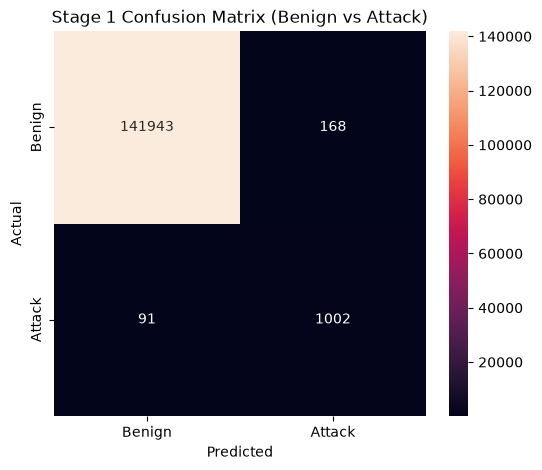

In [45]:
cm = confusion_matrix(y_test_s1, y_pred_s1, labels=["Benign", "Attack"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"], cmap="rocket")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage 1 Confusion Matrix (Benign vs Attack)")
plt.show()


## Stage 1 feature importance

In [46]:
pd.Series(stage1_model.feature_importances_, index=feature_cols).sort_values(ascending=False)


payload_len_std     0.392464
payload_len_mean    0.313736
total_len           0.154958
sttl                0.120328
flow_pkt_count      0.018515
dtype: float64

## Threshold sweep

Scans the precision/recall trade-off across every possible decision
threshold, rather than relying on the default 0.5 cutoff -- useful for
picking an operating point deliberately (e.g. "the highest precision that
still hits at least 60% recall") instead of guessing.

In [47]:
probs = stage1_model.predict_proba(X_test_s1)[:, stage1_model.classes_.tolist().index("Attack")]
precision, recall, thresholds = precision_recall_curve(y_test_s1, probs, pos_label="Attack")

target_recall = 0.6
idx = np.argmin(np.abs(recall - target_recall))
print(f"Closest to recall={target_recall}: threshold={thresholds[idx]:.3f}, "
      f"precision={precision[idx]:.3f}, recall={recall[idx]:.3f}")


Closest to recall=0.6: threshold=1.000, precision=0.995, recall=0.566


## Stage 2: prepare attack-subtype data

Built only from rows whose **true** label is an attack. Classes with a
single session (see the table above) will have zero rows in
`df_test_attacks` -- they were never assigned to test by
`session_level_split`. This is expected, not an error.

In [48]:
df_train_attacks = df_train[df_train["label_binary"] == "Attack"].copy()
df_test_attacks = df_test[df_test["label_binary"] == "Attack"].copy()

print("Stage 2 train:", df_train_attacks.shape, " Stage 2 test:", df_test_attacks.shape)
print("\nTrain labels:")
print(df_train_attacks["label"].value_counts())
print("\nTest labels:")
print(df_test_attacks["label"].value_counts())

missing = set(df_train_attacks["label"]) - set(df_test_attacks["label"])
print("\nAttack types with NO test representation (single-session classes):", missing)


Stage 2 train: (19288, 7)  Stage 2 test: (1093, 7)

Train labels:
label
DNS Flood             12374
Dictionary Attack      3476
Slowloris              2527
Vulnerability Scan      411
Port Scan               341
OS Scan                  66
UDP Flood                59
ICMP Flood               33
SYN Flood                 1
Name: count, dtype: int64

Test labels:
label
Dictionary Attack    513
Slowloris            435
Port Scan            113
DNS Flood             23
OS Scan                9
Name: count, dtype: int64

Attack types with NO test representation (single-session classes): {'SYN Flood', 'UDP Flood', 'Vulnerability Scan', 'ICMP Flood'}


In [49]:
stage2_preprocessor = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), feature_cols),
])

X_train_s2 = stage2_preprocessor.fit_transform(df_train_attacks[feature_cols])
X_test_s2 = stage2_preprocessor.transform(df_test_attacks[feature_cols])

le_stage2 = LabelEncoder()
y_train_s2 = le_stage2.fit_transform(df_train_attacks["label"])
y_test_s2 = le_stage2.transform(df_test_attacks["label"])


## Sqrt-scaled class weights for Stage 2

In [50]:
class_counts = pd.Series(y_train_s2).value_counts()
sqrt_weights = {cls: np.sqrt(class_counts.max() / count) for cls, count in class_counts.items()}
sqrt_weights


{0: np.float64(1.0),
 1: np.float64(1.8867535332634024),
 6: np.float64(2.2128523387006096),
 8: np.float64(5.486989699377115),
 4: np.float64(6.023901562054738),
 3: np.float64(13.69251067134324),
 7: np.float64(14.482016902328281),
 2: np.float64(19.364134294351942),
 5: np.float64(111.23848254988019)}

## Train and evaluate Stage 2

Evaluated only on classes that actually appear in `df_test_attacks` --
i.e. only the multi-session classes. Single-session classes were excluded
from test entirely at the split step, so they cannot appear here; this
report should not be read as "the model handles 10 classes well," but as
"the model handles the N classes with genuine held-out data this well."

In [51]:
stage2_model = RandomForestClassifier(
    n_estimators=300,
    class_weight=sqrt_weights,
    random_state=42,
    n_jobs=-1,
)
stage2_model.fit(X_train_s2, y_train_s2)

y_pred_s2 = stage2_model.predict(X_test_s2)

present_labels = sorted(set(y_test_s2))
print(classification_report(
    y_test_s2, y_pred_s2,
    labels=present_labels,
    target_names=le_stage2.inverse_transform(present_labels),
))


                   precision    recall  f1-score   support

        DNS Flood       0.00      0.00      0.00        23
Dictionary Attack       0.99      0.95      0.97       513
          OS Scan       0.00      0.00      0.00         9
        Port Scan       0.44      0.16      0.23       113
        Slowloris       0.96      1.00      0.98       435

        micro avg       0.94      0.86      0.90      1093
        macro avg       0.48      0.42      0.44      1093
     weighted avg       0.90      0.86      0.87      1093



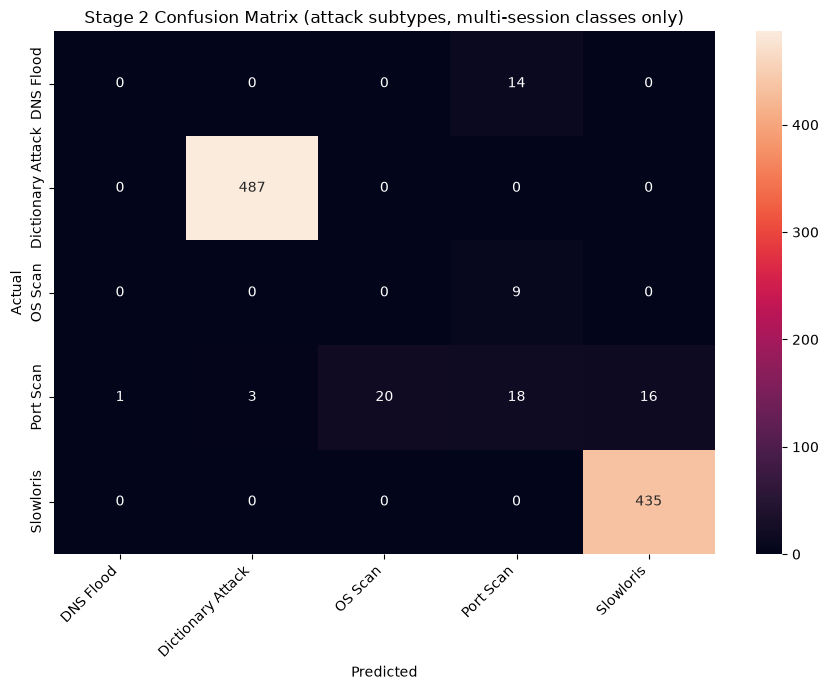

In [52]:
cm2 = confusion_matrix(y_test_s2, y_pred_s2, labels=present_labels)
labels_display = le_stage2.inverse_transform(present_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm2, annot=True, fmt="d", xticklabels=labels_display, yticklabels=labels_display, cmap="rocket")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage 2 Confusion Matrix (attack subtypes, multi-session classes only)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Full pipeline evaluation (Stage 1 → Stage 2 cascade)

The realistic end-to-end number: Stage 1 runs on the full test set first;
rows it predicts "Attack" are passed to Stage 2 for subtyping. This
captures cascading errors -- an attack Stage 1 misses can never reach
Stage 2 and is permanently wrong here, even where Stage 2 alone (previous
cell) would have gotten it right.

In [53]:
X_test_full_s1 = stage1_preprocessor.transform(df_test[feature_cols])
stage1_preds_full = stage1_model.predict(X_test_full_s1)

final_preds = np.array(["Benign"] * len(df_test), dtype=object)
attack_mask = stage1_preds_full == "Attack"

if attack_mask.sum() > 0:
    X_flagged_s2 = stage2_preprocessor.transform(df_test.loc[attack_mask, feature_cols])
    stage2_preds_encoded = stage2_model.predict(X_flagged_s2)
    final_preds[attack_mask] = le_stage2.inverse_transform(stage2_preds_encoded)

y_test_true = df_test["label"].values
print(classification_report(y_test_true, final_preds, zero_division=0))


                    precision    recall  f1-score   support

            Benign       1.00      1.00      1.00    142111
         DNS Flood       0.00      0.00      0.00        23
 Dictionary Attack       0.93      0.95      0.94       513
           OS Scan       0.00      0.00      0.00         9
         Port Scan       0.18      0.08      0.11       113
         Slowloris       0.98      1.00      0.99       435
         UDP Flood       0.00      0.00      0.00         0
Vulnerability Scan       0.00      0.00      0.00         0

          accuracy                           1.00    143204
         macro avg       0.39      0.38      0.38    143204
      weighted avg       1.00      1.00      1.00    143204



## Save the trained models

In [54]:
joblib.dump({
    "stage1_preprocessor": stage1_preprocessor,
    "stage1_model": stage1_model,
    "stage2_preprocessor": stage2_preprocessor,
    "stage2_model": stage2_model,
    "stage2_label_encoder": le_stage2,
    "feature_cols": feature_cols,
}, project_root / "artifacts/two_stage_model_bundle.joblib")


['K:\\Projects\\Machine Learning\\aci-iot-network-traffic\\artifacts\\two_stage_model_bundle.joblib']

## Limitations & Future Work

**Three leakage sources were found and fixed while building this pipeline,
in order of how they were discovered:**

1. **Identity/timestamp leakage** (original single-model version) --
   raw `srcip`, `dstip`, `sport`, `dsport`, `stime`, and `payload` let the
   model memorize *which capture session* a row came from instead of
   learning traffic behavior. Fixed by dropping them as model features
   (keeping `srcip`/`dstip`/`stime` only as grouping/sort keys for feature
   engineering).
2. **Exact duplicate rows across train/test** -- flood/scan traffic is
   highly repetitive, producing many rows with identical feature values;
   roughly 18,900 of ~121,000 test rows (about 15.6%) had an exact
   feature-match sitting in train before deduplication. Fixed by
   deduplicating before splitting.
3. **Single-session classes** -- `ICMP Flood`, `SYN Flood`, `UDP Flood`,
   and `Vulnerability Scan` each exist as exactly **one** continuous
   capture session in this dataset (`SYN Flood` reduces to a single row
   after deduplication). No split strategy -- chronological, per-class,
   or session-based -- can produce a genuinely held-out test set for these
   classes: any test partition of a single session is still testing
   recognition of a different time-slice of the *same* attack execution,
   not detection of a new instance. This is a property of how the dataset
   was captured, not a bug in this pipeline.

**Consequently:** metrics reported above should be trusted only for the
classes with multiple sessions -- Benign, Dictionary Attack, Port Scan,
DNS Flood, OS Scan, and Slowloris. Any near-perfect score attributable to
the four single-session classes reflects within-session recognition, not
attack-detection generalization, and should not be reported as evidence of
real-world detection capability for those specific attack types.

**Even among the fixed classes, Stage 1 (Benign vs. Attack) has a real,
evidenced ceiling:** across weight tuning (5 -> 200), threshold tuning
(down to the most aggressive possible cutoff), and feature pruning,
recall plateaued around 0.5-0.6 on the dataset version before the
session-level fix -- worth re-confirming whether that ceiling still holds
after this cleaner split, since the earlier ceiling was partly measured on
leak-affected data.

**Future work, in priority order:**
- Re-run the weight/threshold sweep on this corrected split and compare
  against the earlier (leak-affected) numbers -- the honest comparison is
  itself worth reporting.
- If a genuinely larger dataset becomes available for the single-session
  classes (more independently-timed attack runs), re-attempt evaluation
  for them specifically.
- Merge in genuine flow-level features from the companion
  `ACI-IoT-2023.csv` (packet rate, distinct ports contacted, connection
  duration) -- likely the highest-leverage remaining improvement for the
  classes that do support real evaluation, based on comparison against a
  public notebook using that richer feature set.